# Tutorial 07: Model Options Reference

## Overview

`GR_disc` takes a lot of keyword arguments. This is the reference for them: what each one
does, what the default is, and when you would change it.

It is not a tutorial you work through — read the summary table, then the section for
whatever you are about to change. Two of these options can change your answer materially,
and they are flagged.

## Prerequisites

- **Tutorial 03: Model Setup and Parameters**

## The summary table

| Option | Default | Change it when |
|--------|---------|----------------|
| `fit_log_m_disc`, `fit_log_r0`, `fit_log_tvi` | `True` | you have an external prior in the linear variable |
| `fit_cos_incl` | `True` | same |
| `radial_grid_spacing` | `'geometric'` | **rarely — see below, this one matters** |
| `default_N` | `None` → 1000 geometric / 3000 linear | you have checked convergence and want more or less |
| `use_dynamic_grid` | `False` | measured on your own data; the `delta_r_in` trap below |
| `delta_r_in` | `0.2` | with the dynamic grid *and* geometric spacing; 0.2 is coarse |
| `use_iv_approximation` | `True` | you are chasing a numerical discrepancy and want it off |
| `weight_by_band` | `False` | **band point counts differ wildly — see below** |
| `band_weights` | `{}` | you want manual control; report what you did |
| `colour_correction` | `True` | comparing against a model without one |
| `decay`, `decay_type`, `rise` | `True`, `'pl'`, `False` | set by the physics you are fitting, not by convenience |

The two in bold are the ones that can move a published number.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# If FitTeD was installed with `pip install -e .` this block is unnecessary.
# It is here so the notebooks also work from a bare checkout.
package_dir = Path().resolve().parent
if str(package_dir) not in sys.path:
    sys.path.append(str(package_dir))   # append, so an installed copy wins

import fitted
fitted.format_plots()

print("FitTeD", fitted.__version__)


  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com




FitTeD 2.0.0


In [2]:
import time
from astropy import units

examples = package_dir / 'fitted' / 'examples'
raw = np.genfromtxt(examples / '2019dsg_Xray.txt', skip_header=3)
kind = np.genfromtxt(examples / '2019dsg_Xray.txt', skip_header=3,
                     usecols=(1), dtype=str)
scale = 4 * np.pi * (236.4 * units.Mpc.to(units.cm))**2
det = kind == 'X'

def make_data(times, lums, errs):
    return fitted.data.Data_Set(args_X=[[times, lums, errs, [0.3, 10]]],
                                   bands_X=['Swift XRT'])

data_compact = make_data(raw[:, 0][det], raw[:, 2][det] * scale,
                         raw[:, 3][det] * scale)

# The same object watched for five years, to show how the grid requirement changes.
t_long = np.concatenate([raw[:, 0][det], np.linspace(300, 1800, 12)])
L_long = np.concatenate([raw[:, 2][det] * scale,
                         raw[:, 2][det][-1] * scale * 0.1 * np.ones(12)])
E_long = np.concatenate([raw[:, 3][det] * scale,
                         raw[:, 3][det][-1] * scale * 0.1 * np.ones(12)])
data_long = make_data(t_long, L_long, E_long)

PHYS = dict(log_mh=7.0, a_bh=0.01, m_disc=0.05, r0=30.0, tvi=15.0, t0=-2.0, incl=70.0)

def timed(model, pars, n=10):
    model.log_likelihood(pars)
    t = time.time()
    for _ in range(n):
        model.log_likelihood(pars)
    return (time.time() - t) / n * 1e3

print("ready")

ready


## 1. Parameter transformations

```python
GR_disc(fit_log_m_disc=True, fit_log_r0=True, fit_log_tvi=True, fit_cos_incl=True)
```

All four are **on by default**. They change which variable the sampler moves in:
`log_m_disc` instead of `m_disc`, `cos_incl` instead of `incl`, and so on.

These are pure changes of variable. At a fixed physical point the likelihood is unchanged;
what changes is the **prior**. Uniform in `log_m_disc` is a Jeffreys prior on `m_disc`;
uniform in `cos_incl` is the isotropic viewing-angle prior. Both are the conventional
choice for their parameter.

**Turn one off** when you have genuine external information in the linear variable — a
black hole mass from an M–σ relation, an inclination from a resolved jet — and want to
impose it directly with a custom `prior=`. Otherwise leave them on: MCMC step sizes are
scale-free in log space, so the sampler does not have to shrink its steps to cope with a
parameter spanning three orders of magnitude.

Build parameter vectors with `pack_parameters()` and none of this can bite you
(Tutorial 03). The check below verifies the likelihood really is unchanged.

In [3]:
linear_model = fitted.models.GR_disc(
    data=data_compact, decay=False,
    fit_log_m_disc=False, fit_log_r0=False, fit_log_tvi=False, fit_cos_incl=False)
log_model = fitted.models.GR_disc(data=data_compact, decay=False)   # defaults

print("linear model samples:", linear_model.default_key_pars)
print("log model samples:   ", log_model.default_key_pars)

L_lin = linear_model.log_likelihood(linear_model.pack_parameters(**PHYS))
L_log = log_model.log_likelihood(log_model.pack_parameters(**PHYS))
print("\nsame physical point, log L: %.12f vs %.12f  (difference %.1e)"
      % (L_lin, L_log, abs(L_lin - L_log)))

def show(b):
    lo, hi = b
    return "(%.4g, %s)" % (lo, "inf" if not np.isfinite(hi) else "%.4g" % hi)

print("\n%-10s %-20s   %-12s %s" % ("linear", "bounds", "sampled", "bounds"))
for a, b in zip(linear_model.default_key_pars, log_model.default_key_pars):
    print("%-10s %-20s   %-12s %s"
          % (a, show(linear_model.default_bounds[a]),
             b, show(log_model.default_bounds[b])))

linear model samples: ['log_mh', 'a_bh', 'm_disc', 'r0', 'tvi', 't0', 'incl']
log model samples:    ['log_mh', 'a_bh', 'log_m_disc', 'log_r0', 'log_tvi', 't0', 'cos_incl']



same physical point, log L: -60.798958933984 vs -60.798958933984  (difference 8.5e-14)

linear     bounds                 sampled      bounds
log_mh     (0, 10)                log_mh       (0, 10)
a_bh       (-0.999, 0.999)        a_bh         (-0.999, 0.999)
m_disc     (0.001, inf)           log_m_disc   (-3, inf)
r0         (1, 1e+04)             log_r0       (0, 4)
tvi        (1, 1000)              log_tvi      (0, 3)
t0         (-100, 365.2)          t0           (-100, 365.2)
incl       (0, 89)                cos_incl     (0.01745, 1)


## 2. Radial grid spacing — the option that matters most

```python
GR_disc(radial_grid_spacing='geometric',   # or 'linear'
        default_N=None)                    # None -> 1000 geometric, 3000 linear
```

The disc temperature profile is computed on a radial grid from the ISCO out to `r_out`,
which the model sets from how far the disc can have spread:

```
r_out ~ max(5 * (t_max - t0) / tvi * r0,  1000)   gravitational radii
```

**`r_out` grows with the length of your light curve.** A 100-day campaign gives
`r_out ~ 10³`; a five-year TDE light curve gives `r_out ~ 10⁴–10⁵`.

A linear grid with fixed `N` therefore spreads its points further and further apart as the
baseline grows, until the inner disc — which produces the X-rays — is resolved by a handful
of cells. A geometric grid keeps a fixed *fractional* resolution everywhere, so extending
`r_out` costs it almost nothing.

In [4]:
def grid_errors(data, phys, Ns=(1000, 3000, 10000), N_ref=120000):
    # Reference = the mean of BOTH schemes at very large N, with their residual
    # disagreement reported. Anchoring on one scheme's fine grid is how you talk
    # yourself into believing the other scheme is broken.
    def mk(sp, N):
        return fitted.models.GR_disc(data=data, decay=False,
                                        use_iv_approximation=False,
                                        radial_grid_spacing=sp, default_N=N)
    refs = {sp: mk(sp, N_ref).log_likelihood(mk(sp, N_ref).pack_parameters(**phys))
            for sp in ('linear', 'geometric')}
    ref = 0.5 * (refs['linear'] + refs['geometric'])
    rows = []
    for sp in ('linear', 'geometric'):
        for N in Ns:
            m = mk(sp, N)
            p = m.pack_parameters(**phys)
            rows.append((sp, N, abs(m.log_likelihood(p) - ref), timed(m, p)))
    return rows, abs(refs['linear'] - refs['geometric'])

for title, data in (("A. 100-day campaign  (r_out ~ 1e3)", data_compact),
                    ("B. five-year baseline (r_out ~ 2e4)", data_long)):
    rows, dis = grid_errors(data, PHYS)
    print("%s   [the two schemes agree to %.1e at N=120000]" % (title, dis))
    print("  %-10s %7s %12s %9s" % ('spacing', 'N', '|d log L|', 'ms'))
    for sp, N, err, msec in rows:
        print("  %-10s %7d %12.2e %9.1f" % (sp, N, err, msec))
    print()

A. 100-day campaign  (r_out ~ 1e3)   [the two schemes agree to 3.5e-03 at N=120000]
  spacing          N    |d log L|        ms
  linear        1000     4.93e-02       6.9
  linear        3000     3.08e-03      19.4
  linear       10000     1.77e-03      89.6
  geometric     1000     4.24e-01       8.1
  geometric     3000     1.40e-01      23.3
  geometric    10000     4.06e-02      99.3



B. five-year baseline (r_out ~ 2e4)   [the two schemes agree to 5.7e-03 at N=120000]
  spacing          N    |d log L|        ms
  linear        1000     1.69e+01      11.7
  linear        3000     1.61e+01      35.1
  linear       10000     6.74e-01     130.9
  geometric     1000     6.65e-01      14.9
  geometric     3000     2.19e-01      47.9
  geometric    10000     6.37e-02     207.1



Read the size of the errors, not just which is smaller.

In **regime A** the linear grid is the more accurate one, by about a factor of ten. But both
are wrong by less than half a log-likelihood unit, and at that level neither choice will
move a fit.

In **regime B** the linear grid is not slightly worse, it is *broken* — wrong by ten or
more in log-likelihood, and still wrong at `N = 10000`. Geometric at `N = 1000` beats linear
at `N = 10000` and is about eight times faster.

> **The asymmetry is the point.** Where linear wins, both schemes are accurate enough not to
> matter. Where geometric wins, linear is catastrophically wrong — and it fails silently.
> `r_out` scales with your baseline, so TDE light curves live in regime B.

On the real six-band AT2019dsg fit in Tutorial 06, with the full two-year baseline, a linear
grid at `N = 3000` is wrong by **more than a hundred** in log-likelihood. That is why
`'geometric'` is the default. Set `'linear'` only to reproduce a pre-2.0 result exactly.

**Choosing `default_N`.** The general method, worth more than any table: pick a
representative parameter point, raise `default_N` until the log-likelihood stops moving, and
use that as your reference. It takes a minute and settles the question for *your* data.

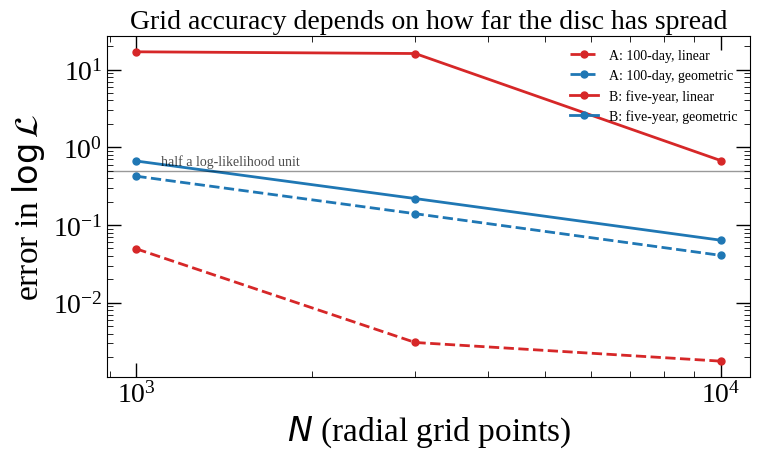

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for data, ls, label in ((data_compact, '--', 'A: 100-day'), (data_long, '-', 'B: five-year')):
    rows, _ = grid_errors(data, PHYS)
    for sp, colour in (('linear', 'C3'), ('geometric', 'C0')):
        pts = [(N, err) for s, N, err, _ in rows if s == sp]
        ax.plot([p[0] for p in pts], [p[1] for p in pts], ls, color=colour,
                marker='o', ms=5, label='%s, %s' % (label, sp))
ax.axhline(0.5, color='k', lw=1, alpha=0.4)
ax.text(1100, 0.6, 'half a log-likelihood unit', fontsize=10, alpha=0.7)
ax.set(xscale='log', yscale='log', xlabel=r'$N$ (radial grid points)',
       ylabel=r'error in $\log \mathcal{L}$',
       title='Grid accuracy depends on how far the disc has spread')
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()
plt.show()

## 3. The dynamic grid, and one trap

```python
GR_disc(use_dynamic_grid=True,
        delta_r_in=0.2,        # inner-edge resolution in r_g -- GEOMETRIC spacing only
        N_per_time_min=300,
        N_per_time_max=3000)
```

Builds a separate grid per epoch, sized to how far the disc has spread by then, instead of
sizing every grid to the final epoch. Off by default.

!!! warning "`delta_r_in` overrides `N_per_time_max` for geometric spacing"

    With geometric spacing the per-epoch grid size comes from `delta_r_in`, **not** from
    `N_per_time_max`. Raising the cap does nothing, and a `delta_r_in` that is too coarse
    gives a fixed error you cannot sample away. The default `0.2` is much too coarse for a
    long baseline.

Which configuration wins depends on which bands you fit. Below it is measured on X-ray-only
data; on the multi-band fit in Tutorial 06 the ranking reverses and the static geometric
default wins, because the optical comes from the outer disc that per-epoch grids truncate.
So: measure it on your own data, or leave it off.

In [6]:
configs = [
    ("static linear N=3000",     dict(radial_grid_spacing='linear', default_N=3000)),
    ("static geometric N=1000",  dict(radial_grid_spacing='geometric', default_N=1000)),
    ("static geometric N=3000",  dict(radial_grid_spacing='geometric', default_N=3000)),
    ("dynamic geometric dr=0.2", dict(radial_grid_spacing='geometric',
                                      use_dynamic_grid=True, delta_r_in=0.2,
                                      N_per_time_min=300, N_per_time_max=3000)),
    ("dynamic linear",           dict(radial_grid_spacing='linear',
                                      use_dynamic_grid=True,
                                      N_per_time_min=300, N_per_time_max=3000)),
]

refs = {}
for sp in ('linear', 'geometric'):
    m = fitted.models.GR_disc(data=data_long, decay=False, use_iv_approximation=False,
                                 radial_grid_spacing=sp, default_N=200000)
    refs[sp] = m.log_likelihood(m.pack_parameters(**PHYS))
ref = refs['linear']
print("five-year X-ray baseline; reference log L = %.6f" % ref)
print("(the two schemes agree to %.1e, so smaller errors are not resolvable here)\n"
      % abs(refs['linear'] - refs['geometric']))

print("  %-27s %11s %9s" % ("configuration", "|d log L|", "ms"))
for label, kw in configs:
    m = fitted.models.GR_disc(data=data_long, decay=False,
                                 use_iv_approximation=False, **kw)
    p = m.pack_parameters(**PHYS)
    print("  %-27s %11.2e %9.1f" % (label, abs(m.log_likelihood(p) - ref), timed(m, p)))

five-year X-ray baseline; reference log L = -91.764108
(the two schemes agree to 3.2e-03, so smaller errors are not resolvable here)

  configuration                 |d log L|        ms


  static linear N=3000           1.61e+01      33.9
  static geometric N=1000        6.68e-01      14.4


  static geometric N=3000        2.21e-01      46.0
  dynamic geometric dr=0.2       1.44e+00      11.6


  dynamic linear                 1.41e-03      46.2


## 4. Band weighting

```python
GR_disc(weight_by_band=True)                        # every band contributes equally
GR_disc(band_weights={'Swift XRT': 2.0, 'g.ztf': 0.5})   # or set them yourself
```

By default every *data point* contributes equally to the likelihood. That is the correct
thing to do statistically — but it means a band's influence is set by how many times it was
observed, and observing cadence is not information.

On AT2019dsg, unbinned, the counts are wildly unequal:

In [7]:
if fitted.data.manyTDE_available == "Yes":
    counts = fitted.data.Data_Set(
        manyTDE_name='AT2019dsg',
        manyTDE_bands=['r.ztf', 'g.ztf', 'UVW1.uvot', 'UVW2.uvot', 'UVM2.uvot'])
    print("%-14s %8s" % ("band", "points"))
    n = {}
    for b in counts.bands_UV:
        n[b] = len(counts.args_band[b][0])
        print("%-14s %8d" % (b, n[b]))
    print("%-14s %8d   (from the shipped example file)" % ('Swift XRT', 10))
    print("\nr.ztf outnumbers UVW1 by %.0f to 1, and the X-ray by %.0f to 1."
          % (n['r.ztf'] / n['UVW1.uvot'], n['r.ztf'] / 10))
else:
    print("manyTDE not installed; the point-count comparison needs it.")
    print("For AT2019dsg the counts are r.ztf 734, g.ztf 468, UVW1 36, UVW2 39,")
    print("UVM2 37, Swift XRT 10 -- so r.ztf outnumbers UVW1 by 20 to 1.")

band             points
r.ztf               734
g.ztf               468
UVW1.uvot            36
UVW2.uvot            39
UVM2.uvot            37
Swift XRT            10   (from the shipped example file)

r.ztf outnumbers UVW1 by 20 to 1, and the X-ray by 73 to 1.


**Why this matters here specifically.** Tutorial 04 showed that on this object the UV band
is what pins the black hole mass down — with X-rays alone the mass came out an order of
magnitude too high. If the optical outvotes the UV twenty to one simply because ZTF observes
more often, the informative band is drowned by the well-sampled one.

There are two ways to deal with it, and the first is usually better:

**Rebin.** Inverse-variance binning reduces a densely sampled band to a number of points
that reflects its information content, without discarding anything. Tutorial 06 bins ZTF
from 734 points to 31, which brings all six bands within a factor of three of each other —
and once you have done that, band weighting is largely unnecessary.

**Weight explicitly.** `weight_by_band=True` gives every band equal total weight regardless
of point count. Use it when rebinning is not appropriate, or as a sensitivity check.

`band_weights` gives manual control; bands not named get weight 1.0.

!!! warning "This is a modelling choice, so report it"

    Down-weighting a band because you dislike what it says is not a statistical procedure.
    The legitimate uses are narrow: cadence not reflecting information content, or a band
    with known unmodelled systematics (host subtraction, say) where you want to show the
    result does not hinge on it. Whatever you choose, say so in the paper — and check
    whether it changes your answer.

## 5. The Bessel approximation

```python
GR_disc(use_iv_approximation=True)     # default
```

The disc solution needs a modified Bessel function `I_{1/3}`, evaluated once per radial grid
point per epoch. With this on, a compiled specialisation replaces `scipy.special.iv`. It is
on by default, it is accurate to far better than anything that could move a fit, and there
is no reason to touch it.

Set `use_iv_approximation=False` if you are chasing a numerical discrepancy and want it off
the list of suspects.

(There is also an `iv_approximation_accuracy` argument. It has no measurable effect for disc
parameters and is best ignored.)

## 6. Configurations worth knowing

| Situation | Settings |
|-----------|----------|
| TDE light curve, months to years | the defaults |
| Short campaign, chasing precision | `radial_grid_spacing='linear'`, `default_N=3000`, `use_iv_approximation=False` |
| Reproducing a pre-2.0 result | as above, plus all `fit_log_*=False` and `fit_cos_incl=False` |
| Chasing a numerical discrepancy | `use_iv_approximation=False`, then raise `default_N` until the answer stops moving |
| Bands with very unequal cadence | rebin first; `weight_by_band=True` as a cross-check |

## Summary

- The parameter transformations leave the likelihood exactly unchanged and change the prior.
- **Grid spacing is the one that can silently ruin a long-baseline fit.** Geometric is the
  default for that reason.
- The dynamic grid's `delta_r_in` overrides `N_per_time_max` for geometric spacing; measure
  before enabling.
- Band weighting is a real modelling choice — prefer rebinning, and report what you did.
- Leave the Bessel approximation alone.

## Further reading

- **Paper Section 2**: the disc solution (arXiv:2408.15048)